In [785]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

#### **Documentación de la API de sklearn**
https://scikit-learn.org/stable/api/index.html

**Feature Selection**

https://scikit-learn.org/stable/modules/feature_selection.html

**Feature Extraction**

https://scikit-learn.org/stable/modules/feature_extraction.html

**Model Selection**

https://scikit-learn.org/stable/api/sklearn.model_selection.html

#### **Preparación y exploración inicial del dataset**

Primero se carga el dataset y se separan las variables explicativas (**X**) de la variable objetivo (**y**, la clase del vino).

Luego el dataset se divide en tres subconjuntos:

- **train (60%)**: usado para entrenar el modelo  
- **validation (20%)**: usado para ajustar hiperparámetros  
- **test (20%)**: usado para evaluar el modelo final  

La división se realiza manteniendo la **misma proporción de clases** mediante `stratify`.

Después se visualizan relaciones entre algunas variables mediante un **pairplot**, coloreando los puntos según la clase.

Finalmente se calcula la **proporción de valores faltantes por columna** para detectar posibles problemas de datos incompletos.

In [786]:
# Carga el dataset
df = pd.read_csv("wine.csv")

# Separa variables (X) y la clase a predecir (y)
X = df.drop("Class", axis=1)
y = df["Class"]

X

,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline,Sugar
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,5.18
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,4.55
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,4.01
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,NaN,3.76
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,NaN,7.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,NaN,0.52,1.06,7.70,0.64,1.74,740.0,5.61
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,NaN,5.16
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,7.00
176,13.17,2.59,2.37,20.0,120,1.65,NaN,0.53,1.46,9.30,0.60,1.62,840.0,4.84


Class                   0.000000
Alcohol                 0.146067
Malic_Acid              0.000000
Ash                     0.000000
Alcalinity_of_Ash       0.000000
Magnesium               0.000000
Total_Phenols           0.000000
Flavanoids              0.247191
Nonflavanoid_Phenols    0.000000
Proanthocyanins         0.000000
Color_Intensity         0.000000
Hue                     0.000000
OD280_OD315             0.000000
Proline                 0.398876
Sugar                   0.000000
dtype: float64

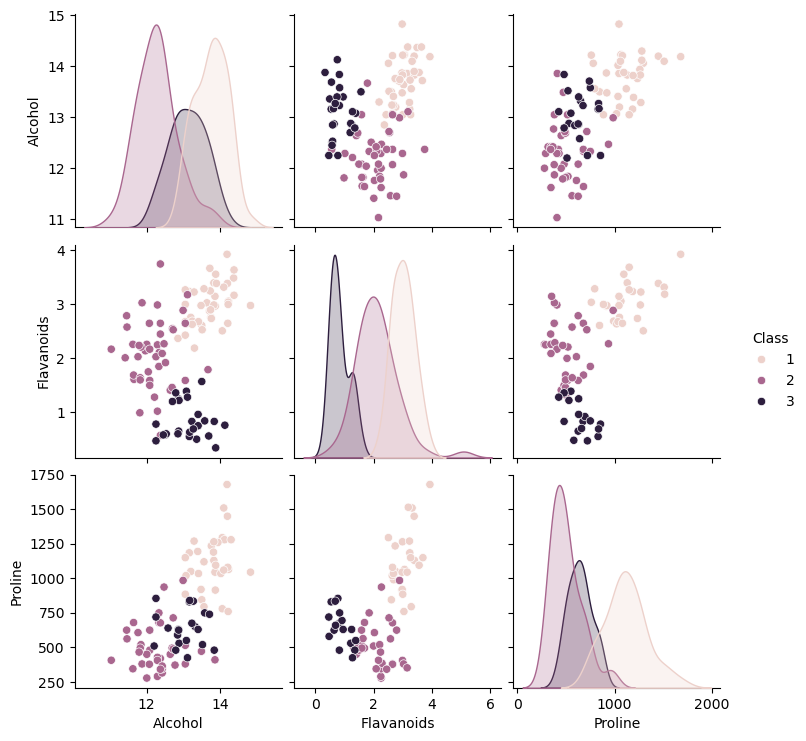

In [787]:

# Train (60%) y temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Dividir temp en validation (20%) y test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Visualiza relaciones entre variables, coloreado por clase
sns.pairplot(df, hue="Class", vars=["Alcohol", "Flavanoids", "Proline"])

# Calcula proporción de valores faltantes por columna
df.isna().sum() / len(df)

#### **Funciones Auxiliares**

`evaluar_knn` crea un modelo **KNN** con los parámetros indicados y evalúa su desempeño.

La función:
- crea el modelo KNN
- ajusta el modelo usando los datos de **entrenamiento**
- realiza predicciones sobre **train** y **validation**
- calcula métricas de desempeño (**accuracy** y **balanced accuracy**)

Finalmente devuelve el **modelo** y un **diccionario con los resultados**.

<br>

$accuracy = \frac{\text{correctos}}{\text{total}}$

$recall = \frac{\text{correctos de esa clase}}{\text{total de esa clase}}$

$balanced\ accuracy = \frac{recall_1 + recall_2 + \dots + recall_C}{C}$

`plot_knn_2d` visualiza el comportamiento de un modelo **KNN** usando solo dos variables del dataset. Nos muestra las fronteras de decisión para cada clase. ¿Qué pasa si modificamos k? 

In [788]:
def evaluar_knn(X_train, y_train, X_val, y_val, 
                n_neighbors=5, metric='minkowski', p=2, weights='uniform'):
    
    """
    X_train, y_train: datos y etiquetas de entrenamiento.
    X_val, y_val: datos y etiquetas de validación.
    n_neighbors: número de vecinos (k).
    metric: métrica de distancia usada por KNN.
    p: parámetro de Minkowski (p=2 → euclidiana).
    weights: ponderación de vecinos ('uniform' o 'distance').

    Devuelve el modelo entrenado y métricas de desempeño.
    """

    np.random.seed(42)

    modelo = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p,
        weights=weights
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    resultados = {
        "k": n_neighbors,
        "metric": metric,
        "p": p,
        "weights": weights,
        "acc_train": accuracy_score(y_train, pred_train),
        "acc_val": accuracy_score(y_val, pred_val),
        "bacc_train": balanced_accuracy_score(y_train, pred_train),
        "bacc_val": balanced_accuracy_score(y_val, pred_val)
    }

    return modelo, resultados

def plot_knn_2d(X_train, y_train, X_val, y_val, cols, n_neighbors=5):

    """
    X_train, y_train: datos y etiquetas de entrenamiento.
    X_val, y_val: datos y etiquetas de validación.
    cols: lista con dos índices de columnas a usar como ejes.
    n_neighbors: número de vecinos del modelo.

    Grafica los puntos y la frontera de decisión de KNN en 2D.
    """

    # seleccionar columnas por índice
    X_train_2d = X_train[:, cols]
    X_val_2d = X_val[:, cols]

    modelo = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelo.fit(X_train_2d, y_train)

    x_min, x_max = X_train_2d[:,0].min() - 1, X_train_2d[:,0].max() + 1
    y_min, y_max = X_train_2d[:,1].min() - 1, X_train_2d[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = modelo.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.25)

    plt.scatter(
        X_train_2d[:,0],
        X_train_2d[:,1],
        c=y_train,
        edgecolor="k",
        label="train"
    )

    plt.scatter(
        X_val_2d[:,0],
        X_val_2d[:,1],
        c=y_val,
        marker="x",
        s=80,
        label="validation"
    )

    plt.xlabel(f"feature {cols[0]}")
    plt.ylabel(f"feature {cols[1]}")
    plt.title(f"KNN decision boundary (k={n_neighbors})")

    plt.legend()
    plt.show()

**¿Funciona este código de abajo?¿Por qué?**

In [789]:
#modelo, res = evaluar_knn(X_train,y_train,X_val,y_val,n_neighbors=5)
#res

#### **Imputación de valores faltantes**

En el dataset existen valores faltantes en algunas variables. Antes de entrenar el modelo es necesario tratarlos.

Algunas estrategias posibles son:

- imputar con la **media** de la variable
- imputar con la **mediana**
- imputar con la **moda** (valor más frecuente)
- **eliminar** las filas con valores faltantes

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean") 

X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

modelo, res = evaluar_knn(
    X_train,
    y_train,
    X_val,
    y_val,
    n_neighbors=5
)

res

{'k': 5,
 'metric': 'minkowski',
 'p': 2,
 'weights': 'uniform',
 'acc_train': 0.8207547169811321,
 'acc_val': 0.7222222222222222,
 'bacc_train': 0.8159824849480022,
 'bacc_val': 0.7214285714285715}

Experimentar graficando las fronteras de decisión con dos features. ¿Qué ocurre al modificar k? ¿Todas las combinaciones de features dividen el espacio de igual forma?

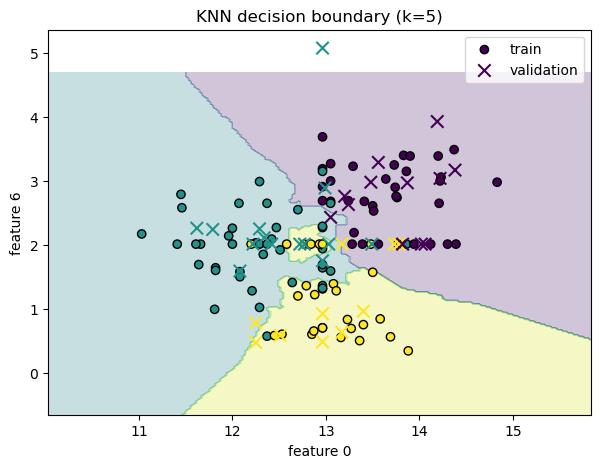

In [ ]:
plot_knn_2d(
    X_train,
    y_train,
    X_val,
    y_val,
    cols=[0, 6],   # features a utilizar 
    n_neighbors=1
)

#### **Outliers**
Analizar si existen valores extremos en el dataset. Visualizar con: boxplots, histogramas, scatter plots.

**Preguntas**

1️⃣ ¿Qué variables presentan valores extremos?

2️⃣ ¿Todos los outliers son necesariamente errores?

3️⃣ ¿Cómo podría afectar esto a KNN?


Probar alguna estrategia para eliminar outliers y reentrenar el modelo, ver cómo afectan a la performance de KNN. ¿Es conveniente eliminarlos?

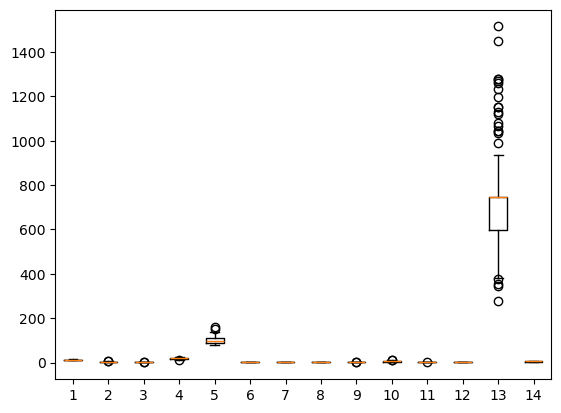

In [ ]:
plt.boxplot(X_train)
plt.show()

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

threshold = 3

mask_train = (abs(X_train) < threshold).all(axis=1)

X_train = X_train[mask_train]
y_train = y_train[mask_train]


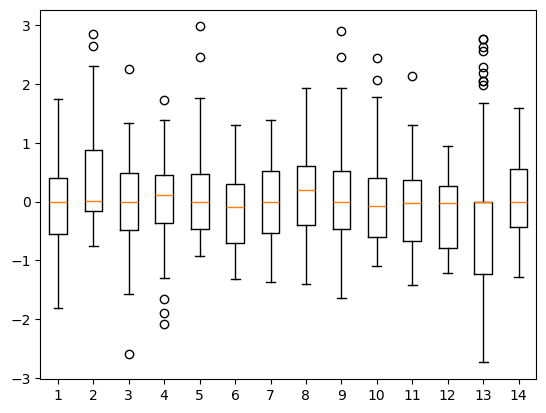

In [ ]:
plt.boxplot(X_train)
plt.show()

In [795]:
modelo, res = evaluar_knn(
    X_train,
    y_train,
    X_val,
    y_val
)

res

{'k': 5,
 'metric': 'minkowski',
 'p': 2,
 'weights': 'uniform',
 'acc_train': 0.979381443298969,
 'acc_val': 0.9444444444444444,
 'bacc_train': 0.9795242396868412,
 'bacc_val': 0.9523809523809524}

#### **Scaling**
Analizar la escala de las variables. Pueden usar `df.describe().T`

**Preguntas**

1️⃣ ¿Las variables tienen escalas similares?

2️⃣ ¿Por qué esto puede ser un problema para KNN?

3️⃣ ¿Qué pasaría si una variable tiene valores mucho más grandes que las demás?


Aplicar distintos scalers: StandardScaler, MinMaxScaler, RobustScaler

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Class,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,152.0,13.013224,0.812942,11.03,12.3625,13.050,13.7125,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity_of_Ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,134.0,2.116642,0.981087,0.34,1.3300,2.225,2.9075,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [797]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

modelo, res = evaluar_knn(
    X_train,
    y_train,
    X_val,
    y_val
)

res

{'k': 5,
 'metric': 'minkowski',
 'p': 2,
 'weights': 'uniform',
 'acc_train': 0.9690721649484536,
 'acc_val': 0.9444444444444444,
 'bacc_train': 0.975609756097561,
 'bacc_val': 0.9523809523809524}

#### **Oversampling y Undersampling**
Examinar la distribución de clases con `y.value_counts()`

**Preguntas**

1️⃣ ¿El dataset está balanceado?

2️⃣ ¿Qué problemas genera el desbalance de clases?
    
3️⃣ ¿Por qué accuracy puede ser engañosa en estos casos?

Probar: Oversampling (Random, SMOTE, ADASYN), Undersampling (Random, NearMiss)


In [ ]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN()

X_train, y_train = adasyn.fit_resample(X_train, y_train)

modelo, res = evaluar_knn(
    X_train,
    y_train,
    X_val,
    y_val
)

res

{'k': 5,
 'metric': 'minkowski',
 'p': 2,
 'weights': 'uniform',
 'acc_train': 0.9504132231404959,
 'acc_val': 0.8888888888888888,
 'bacc_train': 0.9512195121951219,
 'bacc_val': 0.9047619047619048}

#### **Feature Selection + Extraction + Transformation**

Analizar qué variables parecen más informativas y quitar aquellas que no. Se pueden calcular correlaciones para eliminar variables poco correlacionadas con la clase.

Crear nuevas variables a partir de las anteriores combinandolas o aplicandole fórmulas.

In [799]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

selector = SequentialFeatureSelector(
    knn,
    n_features_to_select=5,
    direction="backward"
)

X_train_sel = selector.fit_transform(X_train, y_train)
X_val_sel = selector.transform(X_val)
X_test_sel = selector.transform(X_test)

modelo, res = evaluar_knn(
    X_train_sel,
    y_train,
    X_val_sel,
    y_val
)

X_train = X_train_sel
X_val = X_val_sel
X_test = X_test_sel

res

{'k': 5,
 'metric': 'minkowski',
 'p': 2,
 'weights': 'uniform',
 'acc_train': 0.9669421487603306,
 'acc_val': 0.8611111111111112,
 'bacc_train': 0.9674796747967479,
 'bacc_val': 0.8809523809523809}


#### **Model Selection (K y distancia)**

KNN depende fuertemente del parámetro K.

**Preguntas**

1️⃣ ¿Qué ocurre cuando k = 1?

2️⃣ ¿Qué ocurre cuando k es muy grande?

3️⃣ ¿Cómo afecta esto al overfitting / underfitting?

Evaluar para distintos valores de **k** y modificar la norma de la distancia. ¿Está bien modificar los hiperparámetros en base a una sola partición de validación?


In [800]:
ks = range(1, 25)

resultados = []

for k in ks:

    modelo, res = evaluar_knn(
        X_train,
        y_train,
        X_val,
        y_val,
        n_neighbors=k
    )

    resultados.append(res)

resultados

[{'k': 1,
  'metric': 'minkowski',
  'p': 2,
  'weights': 'uniform',
  'acc_train': 1.0,
  'acc_val': 0.8888888888888888,
  'bacc_train': 1.0,
  'bacc_val': 0.8952380952380952},
 {'k': 2,
  'metric': 'minkowski',
  'p': 2,
  'weights': 'uniform',
  'acc_train': 0.9669421487603306,
  'acc_val': 0.8888888888888888,
  'bacc_train': 0.9674796747967479,
  'bacc_val': 0.8952380952380952},
 {'k': 3,
  'metric': 'minkowski',
  'p': 2,
  'weights': 'uniform',
  'acc_train': 0.9669421487603306,
  'acc_val': 0.9444444444444444,
  'bacc_train': 0.9674796747967479,
  'bacc_val': 0.9523809523809524},
 {'k': 4,
  'metric': 'minkowski',
  'p': 2,
  'weights': 'uniform',
  'acc_train': 0.9586776859504132,
  'acc_val': 0.9166666666666666,
  'bacc_train': 0.959349593495935,
  'bacc_val': 0.9285714285714285},
 {'k': 5,
  'metric': 'minkowski',
  'p': 2,
  'weights': 'uniform',
  'acc_train': 0.9669421487603306,
  'acc_val': 0.8611111111111112,
  'bacc_train': 0.9674796747967479,
  'bacc_val': 0.8809523809

#### **Model Validation**

Utilizar alguna estrategia como LOOCV o k-fold CV para evaluar el modelo y comparar los resultados. Acá pueden probar los variar k y la norma de la distancia. ¿De qué sirve hacer Cross Validation?

In [801]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = np.vstack([X_train, X_val])
y = np.concatenate([y_train, y_val])

resultados = []

for train_idx, val_idx in kf.split(X, y):

    X_train_fold = X[train_idx]
    y_train_fold = y[train_idx]

    X_val_fold = X[val_idx]
    y_val_fold = y[val_idx]

    _, res = evaluar_knn(
        X_train_fold,
        y_train_fold,
        X_val_fold,
        y_val_fold,
        n_neighbors=5
    )

    resultados.append(res["bacc_val"])

print("Scores:", resultados)
print("Mean balanced accuracy:", np.mean(resultados))

Scores: [0.9696969696969697, 0.8787878787878788, 0.9696969696969697, 0.903030303030303, 0.9363636363636364]
Mean balanced accuracy: 0.9315151515151514


#### **Evaluacion Final (Testing)**

In [802]:
_, res = evaluar_knn(
    X_train,
    y_train,
    X_test,
    y_test,
    n_neighbors=5
)

res

{'k': 5,
 'metric': 'minkowski',
 'p': 2,
 'weights': 'uniform',
 'acc_train': 0.9669421487603306,
 'acc_val': 0.3333333333333333,
 'bacc_train': 0.9674796747967479,
 'bacc_val': 0.3333333333333333}